# pandas + duckdb


## load sakila sqlite -> duckdb


In [1]:
import duckdb

# "r" - read mode for the file we open
with open("sql/load_sakila.sql", "r") as sql_file:
    loading_script = sql_file.read()

print(loading_script)

INSTALL sqlite;

LOAD sqlite;

CALL sqlite_attach ('data/sqlite-sakila.db');


In [2]:
type(loading_script)

str

connect to duckdb


In [ ]:
from pathlib import Path

duckdb_path = "data/sakila.duckdb"

# throws away sakila.duckdb if it exists -> makes it idempotent
Path(duckdb_path).unlink(missing_ok=True)

with duckdb.connect(duckdb_path) as conn:
    conn.sql(loading_script)

    description = conn.sql("desc;").df()
    films = conn.sql("FROM film;").df()


description

,database,schema,name,column_names,column_types,temporary
0,sakila,main,actor,"[actor_id, first_name, last_name, last_update]","[DOUBLE, VARCHAR, VARCHAR, TIMESTAMP]",False
1,sakila,main,address,"[address_id, address, address2, district, city...","[BIGINT, VARCHAR, VARCHAR, VARCHAR, BIGINT, VA...",False
2,sakila,main,category,"[category_id, name, last_update]","[BIGINT, VARCHAR, TIMESTAMP]",False
3,sakila,main,city,"[city_id, city, country_id, last_update]","[BIGINT, VARCHAR, BIGINT, TIMESTAMP]",False
4,sakila,main,country,"[country_id, country, last_update]","[BIGINT, VARCHAR, TIMESTAMP]",False
5,sakila,main,customer,"[customer_id, store_id, first_name, last_name,...","[BIGINT, BIGINT, VARCHAR, VARCHAR, VARCHAR, BI...",False
6,sakila,main,customer_list,"[ID, name, address, zip_code, phone, city, cou...","[BIGINT, VARCHAR, VARCHAR, VARCHAR, VARCHAR, V...",False
7,sakila,main,film,"[film_id, title, description, release_year, la...","[BIGINT, VARCHAR, VARCHAR, VARCHAR, BIGINT, BI...",False
8,sakila,main,film_actor,"[actor_id, film_id, last_update]","[BIGINT, BIGINT, TIMESTAMP]",False
9,sakila,main,film_category,"[film_id, category_id, last_update]","[BIGINT, BIGINT, TIMESTAMP]",False


In [4]:
films.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   film_id               1000 non-null   int64         
 1   title                 1000 non-null   object        
 2   description           1000 non-null   object        
 3   release_year          1000 non-null   object        
 4   language_id           1000 non-null   int64         
 5   original_language_id  0 non-null      Int64         
 6   rental_duration       1000 non-null   int64         
 7   rental_rate           1000 non-null   float64       
 8   length                1000 non-null   int64         
 9   replacement_cost      1000 non-null   float64       
 10  rating                1000 non-null   object        
 11  special_features      1000 non-null   object        
 12  last_update           1000 non-null   datetime64[us]
dtypes: Int64(1), dateti

In [5]:
films.columns

Index(['film_id', 'title', 'description', 'release_year', 'language_id',
       'original_language_id', 'rental_duration', 'rental_rate', 'length',
       'replacement_cost', 'rating', 'special_features', 'last_update'],
      dtype='object')

In [ ]:
# query a dataframe variable directly
duckdb.sql("from films;").df().head(2)

,film_id,title,description,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features,last_update
0,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,1,<NA>,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes",2021-03-06 15:52:00
1,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,1,<NA>,3,4.99,48,12.99,G,"Trailers,Deleted Scenes",2021-03-06 15:52:00


## Create a function to query Sakila


In [ ]:
def query_sakila(query: str, duckdb_path="data/sakila.duckdb"):
    with duckdb.connect(duckdb_path) as conn:
        df = conn.sql(query=query).df()

    return df


query_sakila("""
             SELECT 
                actor_id::INT AS actor_id,
                first_name || ' ' || last_name AS actor
             FROM actor
             WHERE first_name ILIKE 'J%' AND last_name ILIKE 'D%';
             """).head()


,actor_id,actor
0,4,JENNIFER DAVIS
1,35,JUDY DEAN
2,41,JODIE DEGENERES
3,123,JULIANNE DENCH


## Join film related dataframes

- film
- film_actor (bridge)
- film_category (bridge)
- actor
- category
- language (join with film)


In [13]:
films_joined = query_sakila("""
    SELECT 
        a.first_name || ' ' || a.last_name AS actor,
        f.title AS film_title,
        f.rating AS film_rating,
        c.name AS category,
        l.name AS language
    FROM film f
        LEFT JOIN film_actor fa ON f.film_id = fa.film_id
        LEFT JOIN actor a ON a.actor_id = fa.actor_id 
        LEFT JOIN film_category fc ON f.film_id = fc.film_id
        LEFT JOIN category c ON c.category_id = fc.category_id
        LEFT JOIN language l ON l.language_id = f.language_id
    ORDER BY 
        film_title
             ;
             """)

films_joined.head(5)

,actor,film_title,film_rating,category,language
0,PENELOPE GUINESS,ACADEMY DINOSAUR,PG,Documentary,English
1,WARREN NOLTE,ACADEMY DINOSAUR,PG,Documentary,English
2,JOHNNY CAGE,ACADEMY DINOSAUR,PG,Documentary,English
3,OPRAH KILMER,ACADEMY DINOSAUR,PG,Documentary,English
4,MENA TEMPLE,ACADEMY DINOSAUR,PG,Documentary,English


how many actors are there in each film?


In [23]:
query_sakila("""
    SELECT
        film_title,
        COUNT(DISTINCT actor) AS actor_count
    FROM films_joined
    GROUP BY film_title
    ORDER BY actor_count DESC;
""").head()

,film_title,actor_count
0,LAMBS CINCINATTI,15
1,DRACULA CRYSTAL,13
2,MUMMY CREATURES,13
3,RANDOM GO,13
4,CHITTY LOCK,13


In [20]:
type(films_joined.groupby("film_title")["actor"].nunique())

pandas.core.series.Series

In [25]:
films_joined.groupby("film_title")["actor"].nunique().sort_values(
    ascending=False
).reset_index().head()

,film_title,actor
0,LAMBS CINCINATTI,15
1,DRACULA CRYSTAL,13
2,MUMMY CREATURES,13
3,CHITTY LOCK,13
4,RANDOM GO,13


In [29]:
total_actors = query_sakila("""
    SELECT
     film_title,
     count (actor) AS total_actors,
    FROM films_joined
    GROUP BY film_title
    ORDER BY total_actors desc;
""")
total_actors.head(5)

,film_title,total_actors
0,LAMBS CINCINATTI,15
1,MUMMY CREATURES,13
2,CHITTY LOCK,13
3,RANDOM GO,13
4,CRAZY HOME,13


In [14]:
films_joined.query("film_title == 'ACADEMY DINOSAUR'")

,actor,film_title,film_rating,category,language
0,PENELOPE GUINESS,ACADEMY DINOSAUR,PG,Documentary,English
1,WARREN NOLTE,ACADEMY DINOSAUR,PG,Documentary,English
2,JOHNNY CAGE,ACADEMY DINOSAUR,PG,Documentary,English
3,OPRAH KILMER,ACADEMY DINOSAUR,PG,Documentary,English
4,MENA TEMPLE,ACADEMY DINOSAUR,PG,Documentary,English
5,ROCK DUKAKIS,ACADEMY DINOSAUR,PG,Documentary,English
6,SANDRA PECK,ACADEMY DINOSAUR,PG,Documentary,English
7,CHRISTIAN GABLE,ACADEMY DINOSAUR,PG,Documentary,English
8,LUCILLE TRACY,ACADEMY DINOSAUR,PG,Documentary,English
9,MARY KEITEL,ACADEMY DINOSAUR,PG,Documentary,English


In [36]:
# with duckdb.sql we can directly query a dataframe
# don't need to connect to an existing database file
duckdb.sql("SELECT film_title, film_rating FROM films_joined").df().head()

,film_title,film_rating
0,ACADEMY DINOSAUR,PG
1,ACADEMY DINOSAUR,PG
2,ACADEMY DINOSAUR,PG
3,ACADEMY DINOSAUR,PG
4,ACADEMY DINOSAUR,PG


## visualization

in visualizations - need to have
- xlabel
- ylabel
- title


### plot in pandas

- dataframe has this "method" plot()
- its a wrapper around matplotlib
- convenience "method" to use


matplotlib.axes._axes.Axes

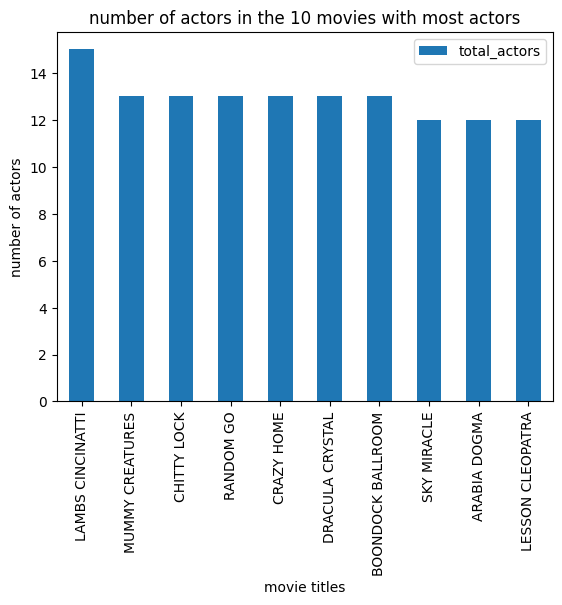

In [ ]:
ax = total_actors.head(10).plot(
    x="film_title",
    y="total_actors",
    kind="bar",
    xlabel="movie titles",
    ylabel="number of actors",
    title = "number of actors in the 10 movies with most actors"
)

# instance of an Axes class
type(ax)

In [54]:
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("actor_count_bar.png", dpi=150)

## draw directly in matplotlib

In [62]:
df = total_actors.head(10)
df

,film_title,total_actors
0,LAMBS CINCINATTI,15
1,MUMMY CREATURES,13
2,CHITTY LOCK,13
3,RANDOM GO,13
4,CRAZY HOME,13
5,DRACULA CRYSTAL,13
6,BOONDOCK BALLROOM,13
7,SKY MIRACLE,12
8,ARABIA DOGMA,12
9,LESSON CLEOPATRA,12


[Text(0.5, 0, 'movie titles'),
 Text(0, 0.5, 'number of actors'),
 Text(0.5, 1.0, 'number of actors in the 10 movies with most actors')]

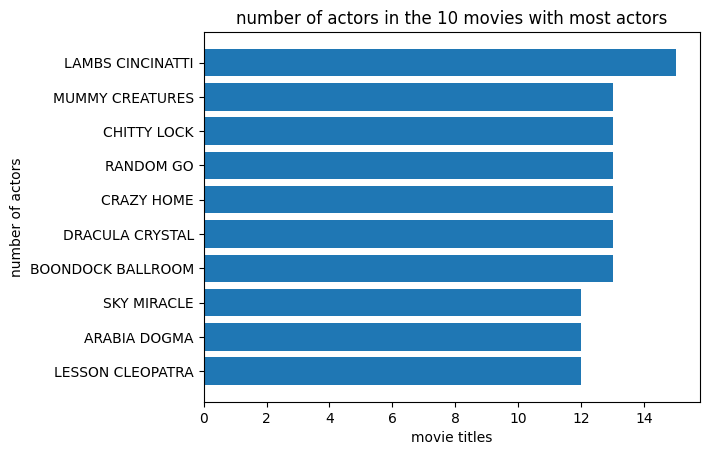

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1)
ax.barh(y=df["film_title"], width=df["total_actors"])
ax.invert_yaxis()
ax.set(
    xlabel="movie titles",
    ylabel="number of actors",
    title="number of actors in the 10 movies with most actors",
)